In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# 1. Read the image into variable
original_img = cv2.imread('cameraman.png')

# 2. Check if it loaded correctly
show_image("Original Input Image", original_img)

<Figure size 600x600 with 0 Axes>

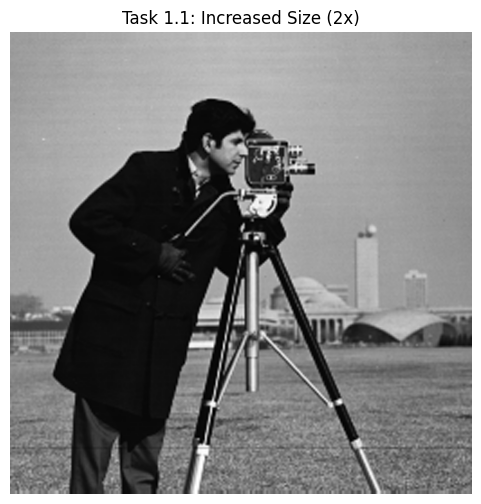

Original shape: (256, 256, 3), Scaled shape: (512, 512, 3)


In [ ]:
#Task 1
# Scale the image by 2x on both axes
# fx and fy are the scale factors
scaled_img = cv2.resize(original_img, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

show_image("Task 1.1: Increased Size (2x)", scaled_img)
print(f"Original shape: {original_img.shape}, Scaled shape: {scaled_img.shape}")

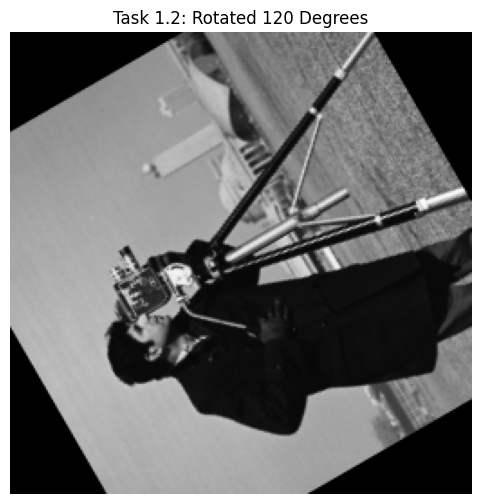

In [26]:
rows, cols, ch = original_img.shape

# Calculate the center of the image
center = (cols / 2, rows / 2)

# Create the rotation matrix: arguments are (center, angle, scale)
rotation_matrix = cv2.getRotationMatrix2D(center, 120, 1.0)

# Apply the affine transformation
rotated_img = cv2.warpAffine(original_img, rotation_matrix, (cols, rows))

show_image("Task 1.2: Rotated 120 Degrees", rotated_img)

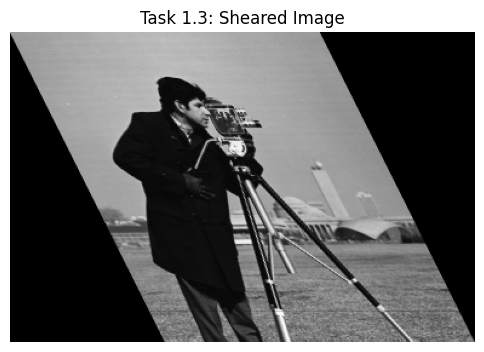

In [27]:
# Shear along the x-axis
shear_factor = 0.5

# Create the Shear Matrix
# [1, shear_factor, 0]
# [0, 1,            0]
shear_matrix = np.float32([[1, shear_factor, 0], [0, 1, 0]])

# Apply warpAffine; we increase the width (cols*1.5) to ensure the sheared part fits
sheared_img = cv2.warpAffine(original_img, shear_matrix, (int(cols * 1.5), rows))

show_image("Task 1.3: Sheared Image", sheared_img)

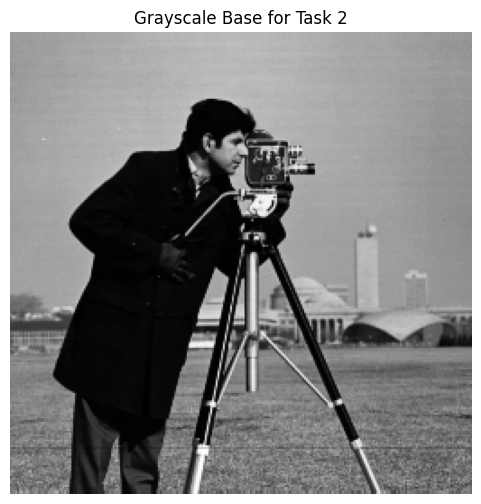

In [28]:
#Task 2: Intensity Transformations
# Convert the original image to grayscale for intensity tasks
gray_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)
show_image("Grayscale Base for Task 2", gray_img, cmap='gray')

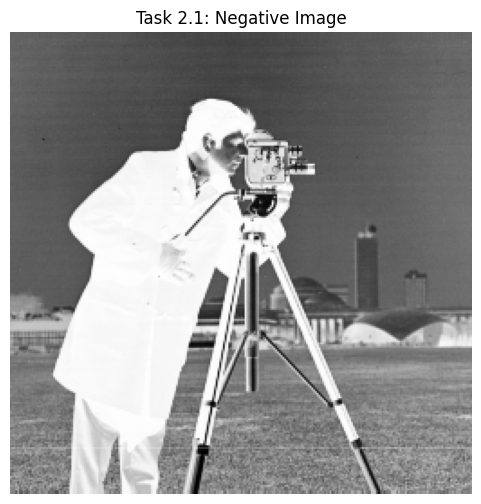

In [29]:
# Formula: s = L - 1 - r (Where L is 256 for 8-bit images)
# 255 - pixel_value gives the negative
negative_img = 255 - gray_img

show_image("Task 2.1: Negative Image", negative_img, cmap='gray')

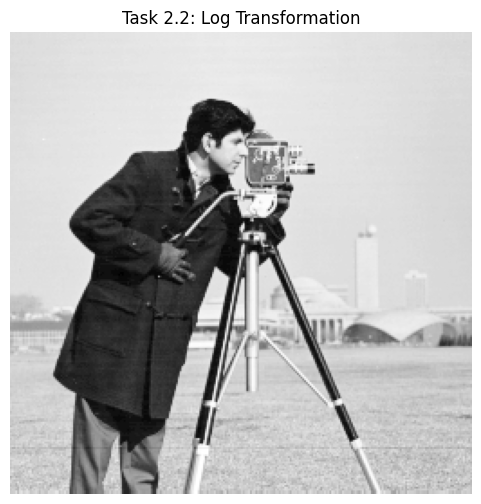

In [30]:
# Formula: s = c * log(1 + r)

# 1. Apply log to the image (add 1 to avoid log(0))
log_base = np.log1p(np.array(gray_img, dtype="float"))

# 2. Calculate constant 'c' to map the output to 0-255 range
c = 255 / np.log(1 + np.max(gray_img))

# 3. Apply the constant and convert back to uint8
log_img = c * log_base
log_img = np.array(log_img, dtype=np.uint8)

show_image("Task 2.2: Log Transformation", log_img, cmap='gray')

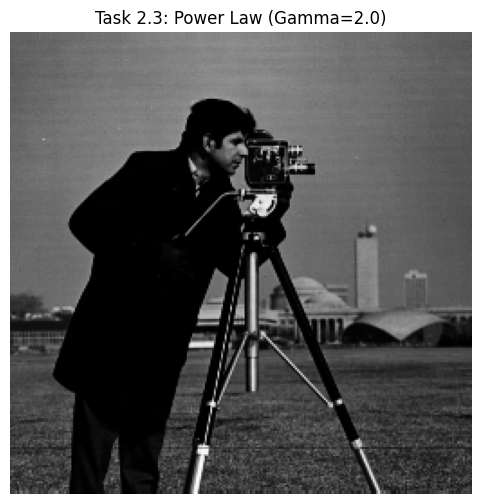

In [31]:
# Formula: s = c * r ^ gamma

# Gamma > 1 expands high intensity (bright) values
# Gamma < 1 expands low intensity (dark) values
gamma = 2.0  # Selected to increase contrast

# 1. Normalize image to range 0.0 - 1.0
normalized_img = gray_img / 255.0

# 2. Apply power law
power_img = np.power(normalized_img, gamma)

# 3. Scale back to 0-255
power_img = np.uint8(power_img * 255)

show_image(f"Task 2.3: Power Law (Gamma={gamma})", power_img, cmap='gray')